In [2]:
# importing required library
import pandas as pd
from pathlib import Path
import csv

df = Path.cwd().parent
cf = df / "data" / "expense.csv"

with open(cf,"r") as d:
    for lin in d:
        lin = lin.strip()
        print(lin)

Date,Item,Amount,Category,Time,day
1/3/2023,chai,7,alone,7:00,Wednesday
1/3/2023,chai,20,friend,10:00,Wednesday
1/3/2023,juice,15,friend,13:00,Wednesday
1/3/2023,rikshow,12,alone,14:00,Wednesday
1/3/2023,coffee,12,alone,15:00,Wednesday
1/3/2023,chai with snaks,25,alone,17:00,Wednesday
1/3/2023,coldrink,10,alone,21:30,Wednesday
1/3/2023,others,10,alone,12:00,Wednesday
2/3/2023,chai,7,alone,7:00,Thursday
2/3/2023,juice,15,friend,13:00,Thursday
2/3/2023,rikshow,12,friend,14:00,Thursday
2/3/2023,coffee,12,alone,15:00,Thursday
2/3/2023,chai with snaks,25,alone,18:00,Thursday
2/3/2023,chiness bhel,60,friend,20:00,Thursday
3/3/2023,chai,7,alone,7:00,Friday
3/3/2023,chai,15,friend,10:00,Friday
3/3/2023,idli,40,friend,10:32,Friday
3/3/2023,others,15,alone,12:00,Friday
3/3/2023,chai with snaks,25,alone,18:00,Friday
3/3/2023,choclate,15,friend,22:30,Friday
4/3/2023,chai,7,alone,7:00,Saturday
4/3/2023,chai,10,friend,10:00,Saturday
4/3/2023,juice,15,alone,12:00,Saturday
4/3/2023,rikshow,12,alone,12

In [6]:
# reading csv file
df = pd.read_csv(cf)

In [9]:
# check for null
df.isnull().sum()

Date        0
Item        0
Amount      0
Category    1
Time        0
day         0
dtype: int64

In [31]:
# exact no of null in rows
row_check = df.isnull().any(axis=1)
print(row_check.sum())

1


In [30]:
# Displys a nan/empty value exactly
df[df.isnull().any(axis=1)]

,Date,Item,Amount,Category,Time,day
72,12/3/2023,others,10,NaN,18:30,Sunday


In [29]:
# check for all empty values in a row
df[df.isnull().all(axis=1)]

,Date,Item,Amount,Category,Time,day


In [17]:
print("Any missing values?", df.isnull().values.any())
print("Rows with at least one null:", df.isnull().any(axis=1).sum())
print("Completely empty rows:", df.isnull().all(axis=1).sum())

Any missing values? True
Rows with at least one null: 1
Completely empty rows: 0


In [22]:
print(df.isnull().values.any())
print(df.isnull().all(axis=1).sum())
print(df.isnull().any(axis=1).sum())

True
0
1


In [28]:
print(df[df.isnull().any(axis=1)])

         Date    Item  Amount Category   Time     day
72  12/3/2023  others      10      NaN  18:30  Sunday


In [33]:
# mode for category
df["Category"] = df["Category"].fillna(df["Category"].mode()[0])

In [34]:
print(df[df.isnull().any(axis=1)])

Empty DataFrame
Columns: [Date, Item, Amount, Category, Time, day]
Index: []


In [35]:
df.isnull().any(axis=1).sum()

np.int64(0)

In [36]:
df["Category"].mode()

0    alone
Name: Category, dtype: str

In [165]:
# printing a specific row 
df.loc[df.index == 72]

,Date,Item,Amount,Category,Time,day,year,month,weekday,is_weekend,day_type,hour
72,2023-12-03,others,10,alone,18:30,3,2023,12,Sunday,True,Weekend,18.0


In [164]:
df.iloc[72]   

Date          2023-12-03 00:00:00
Item                     coldrink
Amount                         20
Category                   friend
Time                        14:10
day                             3
year                         2023
month                          12
weekday                    Sunday
is_weekend                   True
day_type                  Weekend
hour                         14.0
Name: 68, dtype: object

In [39]:
df.isnull().sum()

Date        0
Item        0
Amount      0
Category    0
Time        0
day         0
dtype: int64

In [40]:
# Date 
df["Date"].dtypes

<StringDtype(storage='python', na_value=nan)>

In [59]:
df["Date"]=pd.to_datetime(df["Date"],dayfirst=True,errors = "coerce")
# df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y", errors="coerce") -- same

In [60]:
df["Date"].dtypes

dtype('<M8[us]')

In [61]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["weekday"] = df["Date"].dt.day_name()

In [62]:
df["Date"].min()

Timestamp('2023-01-03 00:00:00')

In [63]:
df["Date"].max()

Timestamp('2023-12-03 00:00:00')

In [64]:
df= df.sort_values("Date")


In [72]:
df[["Date","Amount","Item"]].head(20)

,Date,Amount,Item
0,2023-01-03,7,chai
1,2023-01-03,20,chai
2,2023-01-03,15,juice
3,2023-01-03,12,rikshow
4,2023-01-03,12,coffee
5,2023-01-03,25,chai with snaks
6,2023-01-03,10,coldrink
7,2023-01-03,10,others
8,2023-02-03,7,chai
9,2023-02-03,15,juice


In [66]:
df[["Date","Amount","Item"]].tail(20)

,Date,Amount,Item
125,NaT,20,chai with snaks
126,NaT,10,chai
127,NaT,70,juice
128,NaT,12,rikshow
129,NaT,180,biryani
130,NaT,20,coldrink
131,NaT,15,chai with snaks
132,NaT,45,chai with snaks
133,NaT,45,others
134,NaT,15,chai with snaks


In [71]:
df[df["Date"].isna()]

,Date,Item,Amount,Category,Time,day,year,month,weekday
73,NaT,chai,10,alone,7:00,NaN,NaN,NaN,NaN
74,NaT,petrol,70,friend,10:00,NaN,NaN,NaN,NaN
75,NaT,juice,25,friend,11:00,NaN,NaN,NaN,NaN
76,NaT,coffee,12,alone,17:00,NaN,NaN,NaN,NaN
77,NaT,others,30,friend,18:00,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
140,NaT,chai with snaks,15,alone,17:30,NaN,NaN,NaN,NaN
141,NaT,others,20,alone,19:00,NaN,NaN,NaN,NaN
142,NaT,chai with snaks,15,alone,9:00,NaN,NaN,NaN,NaN
143,NaT,coldrink,20,friend,15:00,NaN,NaN,NaN,NaN


In [68]:
# space check incase
df["Date"] = df["Date"].astype(str).str.strip()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [70]:
df["Date"].isna().sum()

np.int64(72)

In [73]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

In [74]:
df["Date"].isna().sum()

np.int64(72)

In [77]:
df.head()

,Date,Item,Amount,Category,Time,day,year,month,weekday
0,2023-01-03,chai,7,alone,7:00,3.0,2023.0,1.0,Tuesday
1,2023-01-03,chai,20,friend,10:00,3.0,2023.0,1.0,Tuesday
2,2023-01-03,juice,15,friend,13:00,3.0,2023.0,1.0,Tuesday
3,2023-01-03,rikshow,12,alone,14:00,3.0,2023.0,1.0,Tuesday
4,2023-01-03,coffee,12,alone,15:00,3.0,2023.0,1.0,Tuesday


In [78]:
df.tail()

,Date,Item,Amount,Category,Time,day,year,month,weekday
140,NaT,chai with snaks,15,alone,17:30,NaN,NaN,NaN,NaN
141,NaT,others,20,alone,19:00,NaN,NaN,NaN,NaN
142,NaT,chai with snaks,15,alone,9:00,NaN,NaN,NaN,NaN
143,NaT,coldrink,20,friend,15:00,NaN,NaN,NaN,NaN
144,NaT,chai with snaks,25,alone,17:00,NaN,NaN,NaN,NaN


In [79]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["weekday"] = df["Date"].dt.day_name()

In [80]:
df[df["Date"].isna()]


,Date,Item,Amount,Category,Time,day,year,month,weekday
73,NaT,chai,10,alone,7:00,NaN,NaN,NaN,NaN
74,NaT,petrol,70,friend,10:00,NaN,NaN,NaN,NaN
75,NaT,juice,25,friend,11:00,NaN,NaN,NaN,NaN
76,NaT,coffee,12,alone,17:00,NaN,NaN,NaN,NaN
77,NaT,others,30,friend,18:00,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
140,NaT,chai with snaks,15,alone,17:30,NaN,NaN,NaN,NaN
141,NaT,others,20,alone,19:00,NaN,NaN,NaN,NaN
142,NaT,chai with snaks,15,alone,9:00,NaN,NaN,NaN,NaN
143,NaT,coldrink,20,friend,15:00,NaN,NaN,NaN,NaN


In [167]:
df = df.sort_values("Date")  # ensure sorted first
df["Date"] = df["Date"].ffill() # Use .ffill() instead of .fillna(method=...)


In [168]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["weekday"] = df["Date"].dt.day_name()


In [169]:
print("NaT count:", df["Date"].isna().sum())


NaT count: 0


In [170]:
# print("NaT count:", df["Date"].isna().sum())
df.head()
# df.tail()

,Date,Item,Amount,Category,Time,day,year,month,weekday,is_weekend,day_type,hour
0,2023-01-03,chai,7,alone,7:00,3,2023,1,Tuesday,False,Weekday,7.0
1,2023-01-03,chai,20,friend,10:00,3,2023,1,Tuesday,False,Weekday,10.0
2,2023-01-03,juice,15,friend,13:00,3,2023,1,Tuesday,False,Weekday,13.0
3,2023-01-03,rikshow,12,alone,14:00,3,2023,1,Tuesday,False,Weekday,14.0
4,2023-01-03,coffee,12,alone,15:00,3,2023,1,Tuesday,False,Weekday,15.0


In [90]:
df.tail()

,Date,Item,Amount,Category,Time,day,year,month,weekday
140,2023-12-03,chai with snaks,15,alone,17:30,NaN,2023,12,Sunday
141,2023-12-03,others,20,alone,19:00,NaN,2023,12,Sunday
142,2023-12-03,chai with snaks,15,alone,9:00,NaN,2023,12,Sunday
143,2023-12-03,coldrink,20,friend,15:00,NaN,2023,12,Sunday
144,2023-12-03,chai with snaks,25,alone,17:00,NaN,2023,12,Sunday


In [91]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["weekday"] = df["Date"].dt.day_name()


In [92]:
df.tail()

,Date,Item,Amount,Category,Time,day,year,month,weekday
140,2023-12-03,chai with snaks,15,alone,17:30,NaN,2023,12,Sunday
141,2023-12-03,others,20,alone,19:00,NaN,2023,12,Sunday
142,2023-12-03,chai with snaks,15,alone,9:00,NaN,2023,12,Sunday
143,2023-12-03,coldrink,20,friend,15:00,NaN,2023,12,Sunday
144,2023-12-03,chai with snaks,25,alone,17:00,NaN,2023,12,Sunday


In [94]:
df = df.sort_values("Date")  # ensure sorted first
df["Date"] = df["Date"].ffill()

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day 
df["weekday"] = df["Date"].dt.day_name()

In [95]:
df.tail()

,Date,Item,Amount,Category,Time,day,year,month,weekday
141,2023-12-03,others,20,alone,19:00,3,2023,12,Sunday
142,2023-12-03,chai with snaks,15,alone,9:00,3,2023,12,Sunday
106,2023-12-03,juice,25,friend,12:00,3,2023,12,Sunday
72,2023-12-03,others,10,alone,18:30,3,2023,12,Sunday
144,2023-12-03,chai with snaks,25,alone,17:00,3,2023,12,Sunday


In [96]:
df.head()

,Date,Item,Amount,Category,Time,day,year,month,weekday
0,2023-01-03,chai,7,alone,7:00,3,2023,1,Tuesday
1,2023-01-03,chai,20,friend,10:00,3,2023,1,Tuesday
2,2023-01-03,juice,15,friend,13:00,3,2023,1,Tuesday
3,2023-01-03,rikshow,12,alone,14:00,3,2023,1,Tuesday
4,2023-01-03,coffee,12,alone,15:00,3,2023,1,Tuesday


In [97]:
df["Date"].isna().sum()

np.int64(0)

In [99]:
df["Date"].max()

Timestamp('2023-12-03 00:00:00')

In [100]:
# total per day
daily_total = df.groupby("Date")["Amount"].sum()
print(daily_total)

Date
2023-01-03     111
2023-02-03     131
2023-03-03     117
2023-04-03     126
2023-05-03     632
2023-06-03      71
2023-07-03     432
2023-08-03     422
2023-09-03      60
2023-10-03      47
2023-11-03     154
2023-12-03    2306
Name: Amount, dtype: int64


In [101]:
daily_total_df = df.groupby("Date",as_index=False)["Amount"].sum()
print(daily_total_df)

         Date  Amount
0  2023-01-03     111
1  2023-02-03     131
2  2023-03-03     117
3  2023-04-03     126
4  2023-05-03     632
5  2023-06-03      71
6  2023-07-03     432
7  2023-08-03     422
8  2023-09-03      60
9  2023-10-03      47
10 2023-11-03     154
11 2023-12-03    2306


In [103]:
# sort by date
daily_total_df=daily_total_df.sort_values("Date")
daily_total_df.head()

,Date,Amount
0,2023-01-03,111
1,2023-02-03,131
2,2023-03-03,117
3,2023-04-03,126
4,2023-05-03,632


In [104]:
# sort by spending day
daily_total_df = daily_total_df.sort_values("Amount",ascending = False)
daily_total_df.head()

,Date,Amount
11,2023-12-03,2306
4,2023-05-03,632
6,2023-07-03,432
7,2023-08-03,422
10,2023-11-03,154


<Axes: title={'center': 'Daily Sending'}, ylabel='Date'>

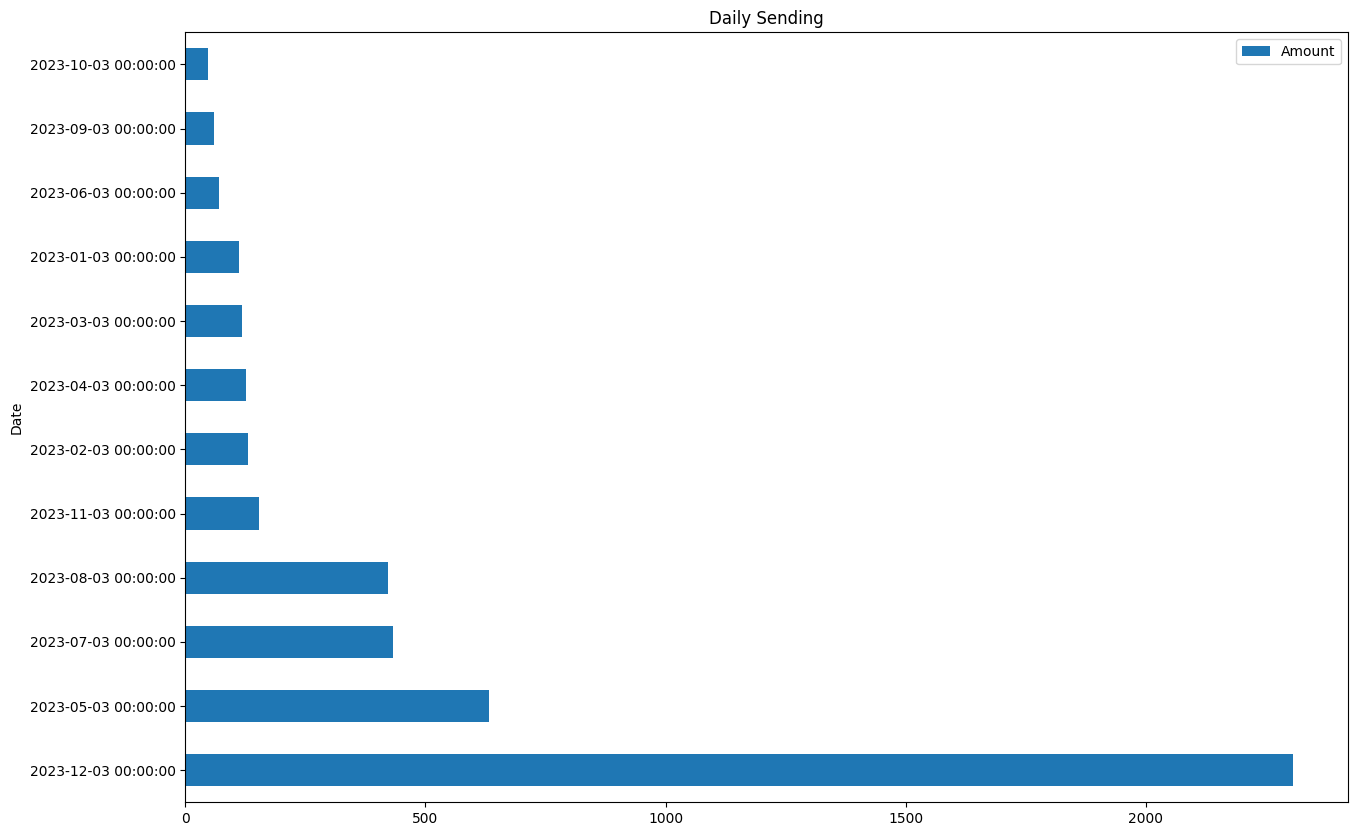

In [115]:
daily_total_df.plot(x="Date",y="Amount",kind="barh",figsize=(15,10),title="Daily Sending")

In [116]:
# Amount
category_total = df.groupby("Category")["Amount"].sum()
print(category_total)

Category
alone     2720
friend    1889
Name: Amount, dtype: int64


In [118]:
category_total_df = df.groupby("Category",as_index=False)["Amount"].sum()
print(category_total_df)

  Category  Amount
0    alone    2720
1   friend    1889


In [121]:
category_total_df_sort = category_total_df.sort_values("Amount",ascending=False)
category_total_df_sort

,Category,Amount
0,alone,2720
1,friend,1889


<Axes: title={'center': 'Total Spending: Alone vs Friend'}, xlabel='Category'>

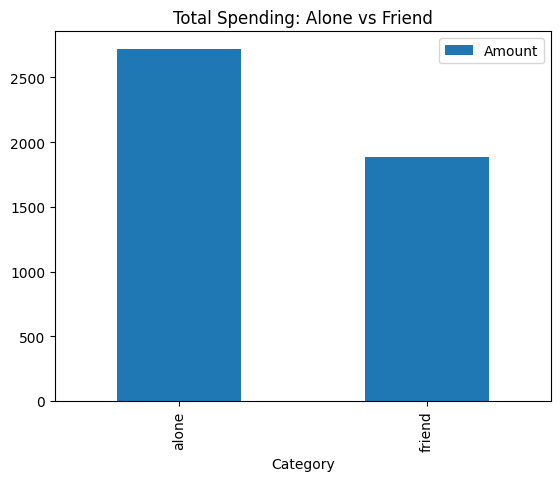

In [122]:
category_total_df.plot(x="Category", y="Amount", kind="bar", title="Total Spending: Alone vs Friend")

In [124]:
# item
item_max_spent = df.groupby("Item")["Amount"].sum()
print(item_max_spent)

Item
biryani             580
chai                200
chai with snaks    1080
chass                17
chicken             180
chiness bhel         60
choclate             15
coffee              120
coldrink            165
faluda               50
freanky              70
ice cream            65
idli                105
juice               210
maggi                30
others              335
petrol               70
pizza               100
recharge            210
rikshow              48
samosa               49
shoe                500
wifi                350
Name: Amount, dtype: int64


In [127]:
item_total_df = df.groupby("Item",as_index=False)["Amount"].sum()
print(item_total_df)

               Item  Amount
0           biryani     580
1              chai     200
2   chai with snaks    1080
3             chass      17
4           chicken     180
5      chiness bhel      60
6          choclate      15
7            coffee     120
8          coldrink     165
9            faluda      50
10          freanky      70
11        ice cream      65
12             idli     105
13            juice     210
14            maggi      30
15           others     335
16           petrol      70
17            pizza     100
18         recharge     210
19          rikshow      48
20           samosa      49
21             shoe     500
22             wifi     350


In [133]:
item_total_df = item_total_df.sort_values("Amount",ascending=False)
item_total_df.head()

,Item,Amount
2,chai with snaks,1080
0,biryani,580
21,shoe,500
22,wifi,350
15,others,335


<Axes: title={'center': 'Most Expensive Items'}, xlabel='Item'>

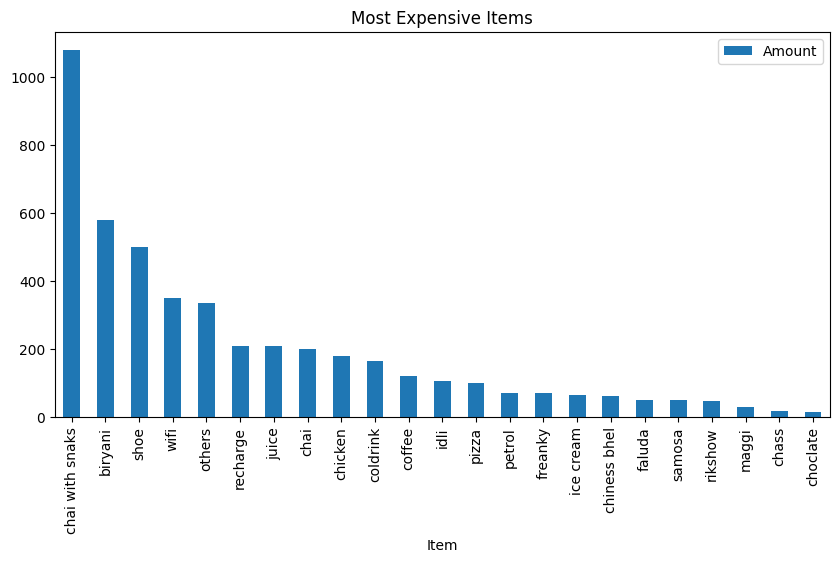

In [134]:
item_total_df.plot(x="Item",y="Amount",kind="bar",figsize=(10,5),title="Most Expensive Items")

In [136]:
item_total_df.max()

Item      wifi
Amount    1080
dtype: object

In [137]:
item_max_spent.max()

np.int64(1080)

In [138]:
# weekends vs weekdays
df["is_weekend"] = df["Date"].dt.weekday >=5


In [139]:
df["day_type"] = df["is_weekend"].map({True:"Weekend",False:"Weekday"})

In [141]:
daytype_total = df.groupby("day_type")["Amount"].sum()
print(daytype_total)

day_type
Weekday    2172
Weekend    2437
Name: Amount, dtype: int64


In [143]:
daytype_total_df = df.groupby("day_type",as_index = False)["Amount"].sum()
daytype_total_df

,day_type,Amount
0,Weekday,2172
1,Weekend,2437


<Axes: title={'center': 'Spending : Weekday vs Weekends'}, xlabel='day_type'>

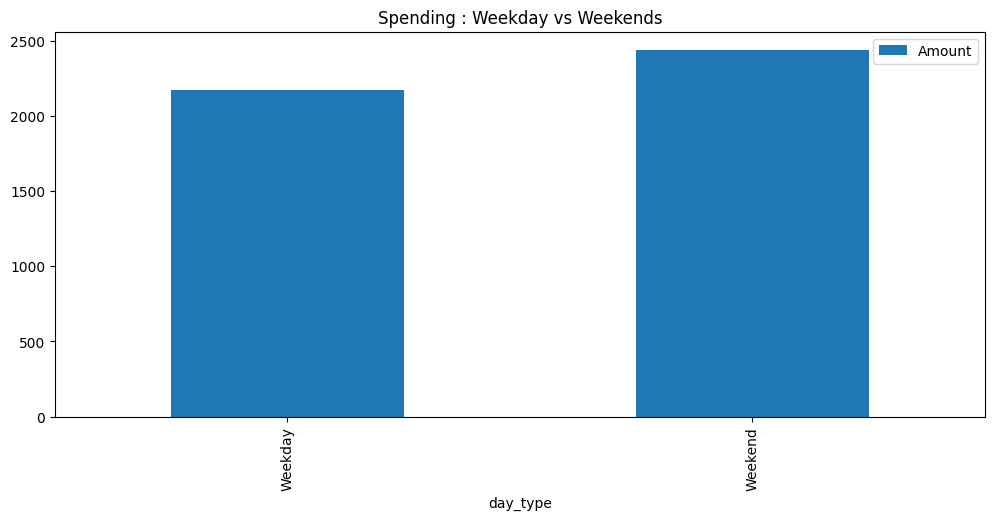

In [158]:
daytype_total_df.plot(x="day_type",y="Amount",kind="bar",figsize=(12,5),title="Spending : Weekday vs Weekends")

In [150]:
# time 
df["hour"] = pd.to_datetime(df["Time"],format="%H:%M",errors ="coerce").dt.hour

In [151]:
df[["Time","hour"]].head()

,Time,hour
0,7:00,7.0
1,10:00,10.0
2,13:00,13.0
3,14:00,14.0
4,15:00,15.0


In [152]:
hourly_total = df.groupby("hour")["Amount"].sum()
print(hourly_total)

hour
7.0      72
9.0     605
10.0    600
11.0     85
12.0    387
13.0    202
14.0    188
15.0    246
16.0    200
17.0    814
18.0    312
19.0    164
20.0     74
21.0    385
22.0     65
23.0    200
Name: Amount, dtype: int64


In [153]:
hourly_total_df = df.groupby("hour", as_index=False)["Amount"].sum()
hourly_total_df


,hour,Amount
0,7.0,72
1,9.0,605
2,10.0,600
3,11.0,85
4,12.0,387
5,13.0,202
6,14.0,188
7,15.0,246
8,16.0,200
9,17.0,814


<Axes: title={'center': 'Spending by Hour of Day'}, xlabel='hour'>

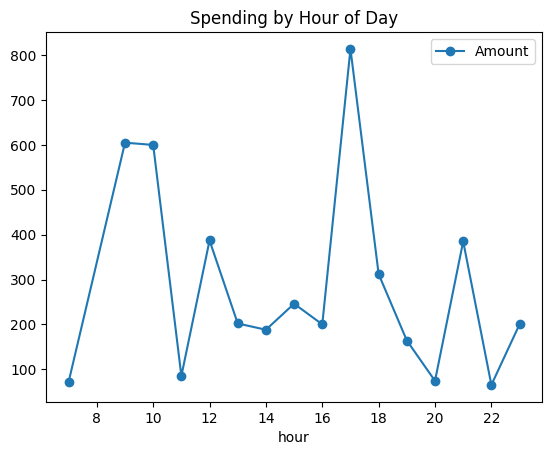

In [154]:
hourly_total_df.plot(x="hour", y="Amount", kind="line", marker="o", title="Spending by Hour of Day")

In [155]:
hour_daytype = df.groupby(["day_type", "hour"])["Amount"].sum().reset_index()
hour_daytype

,day_type,hour,Amount
0,Weekday,7.0,55
1,Weekday,9.0,70
2,Weekday,10.0,530
3,Weekday,11.0,15
4,Weekday,12.0,117
5,Weekday,13.0,30
6,Weekday,14.0,36
7,Weekday,15.0,46
8,Weekday,17.0,597
9,Weekday,18.0,82


<Axes: title={'center': 'Weekday vs Weekends'}, xlabel='hour'>

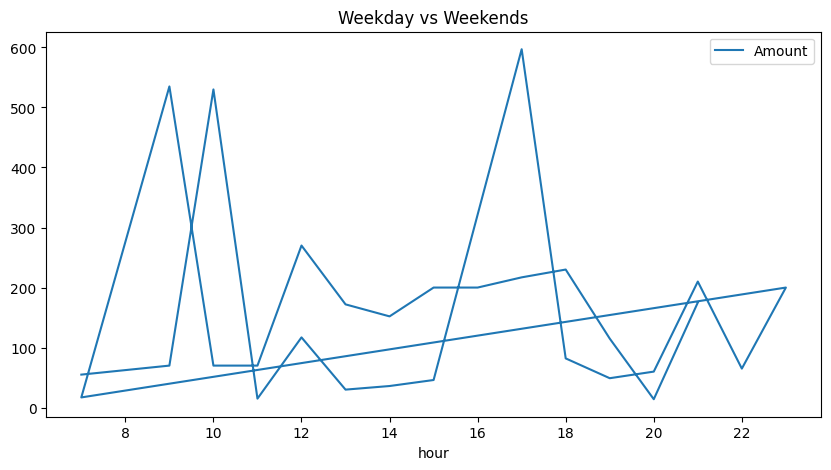

In [161]:
hour_daytype.plot(x="hour",y="Amount",kind="line",figsize=(10,5),title="Weekday vs Weekends")

In [163]:
# days
day_ofweek = df.groupby("day")["Amount"].sum()
print(day_ofweek)

day
3    4609
Name: Amount, dtype: int64


<Axes: title={'center': 'Daily Sending'}, ylabel='Date'>

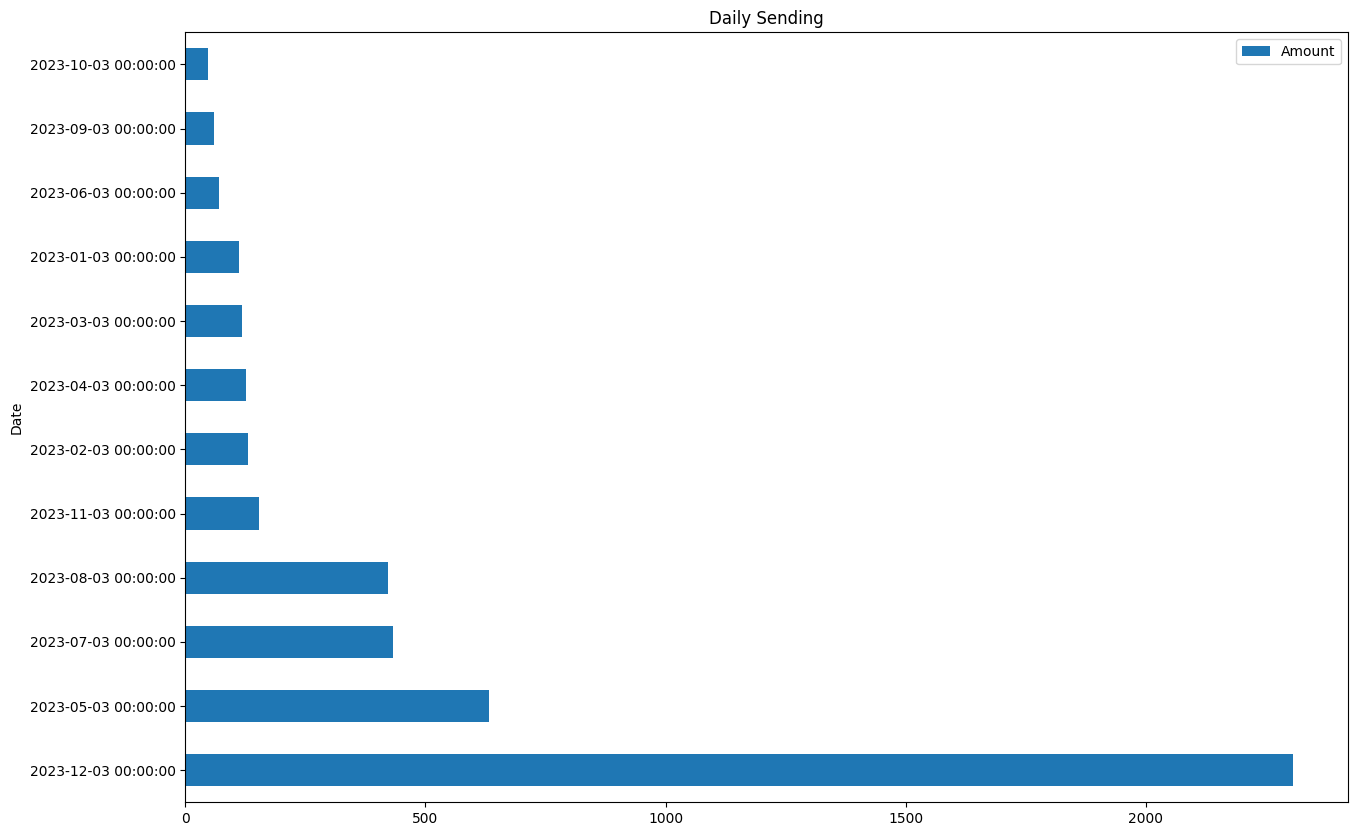

In [171]:
daily_total_df.plot(x="Date",y="Amount",kind="barh",figsize=(15,10),title="Daily Sending")

<Axes: title={'center': 'Total Spending: Alone vs Friend'}, xlabel='Category'>

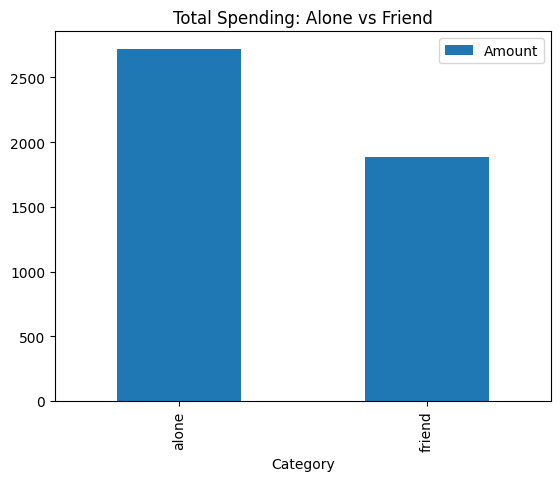

In [172]:
category_total_df.plot(x="Category", y="Amount", kind="bar", title="Total Spending: Alone vs Friend")

<Axes: title={'center': 'Spending by Hour of Day'}, xlabel='hour'>

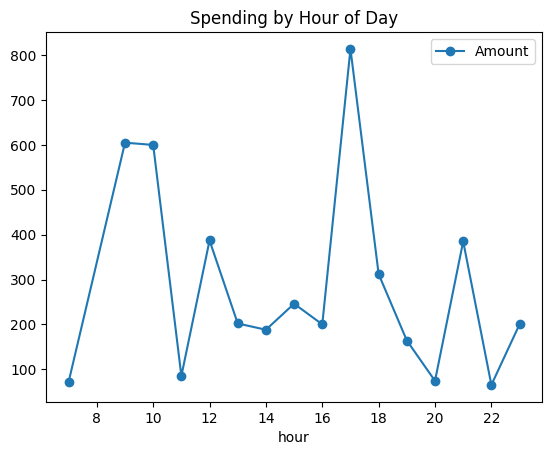

In [173]:
hourly_total_df.plot(x="hour", y="Amount", kind="line", marker="o", title="Spending by Hour of Day")

<Axes: title={'center': 'Weekday vs Weekends'}, xlabel='hour'>

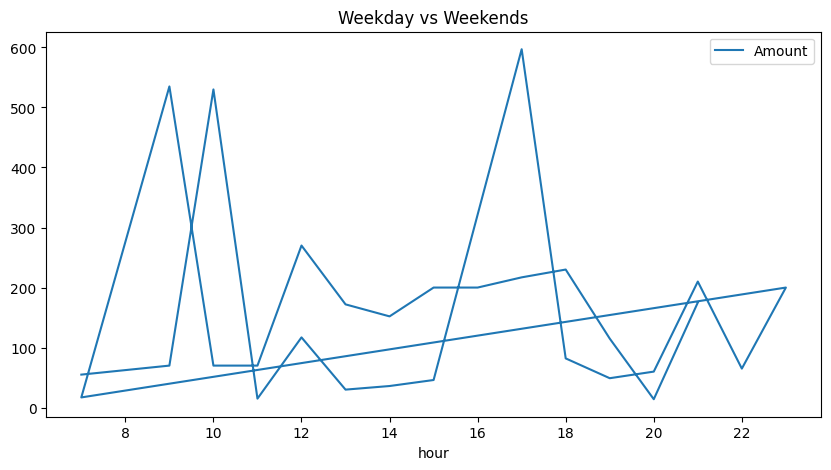

In [174]:
hour_daytype.plot(x="hour",y="Amount",kind="line",figsize=(10,5),title="Weekday vs Weekends")